[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/13_simple_search/notebooks/02_busqueda.ipynb)


# Notebook 2: Búsqueda No Informada — BFS, DFS e IDDFS

Implementaremos el **algoritmo genérico de búsqueda** y veremos cómo BFS, DFS e IDDFS son instancias del mismo código con diferentes fronteras.

La idea central es elegante: el algoritmo en sí no cambia. Lo que cambia es la **estructura de datos** que usamos como frontera:

| Algoritmo | Frontera | Garantía |
|-----------|----------|----------|
| BFS | Cola (FIFO) | Camino óptimo en grafos sin pesos |
| DFS | Pila (LIFO) | Sin garantía de optimalidad |
| IDDFS | Pila con límite, iterando | Óptimo + memoria de DFS |

Todos operan en tiempo $O(V + E)$ en el peor caso.


In [1]:
# Solo en Colab — en entorno local estas librerías ya deben estar instaladas
import sys
if "google.colab" in sys.modules:
    !pip install -q numpy matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

COLORS = {
    "primary":   "#2563EB",
    "secondary": "#10B981",
    "accent":    "#F59E0B",
    "danger":    "#EF4444",
    "wall":      "#374151",
    "path":      "#BAE6FD",
    "start":     "#F97316",
    "goal":      "#22C55E",
    "empty":     "#F9FAFB",
}

print("Dependencias cargadas.")


Dependencias cargadas.


---
## Sección 1: El Algoritmo Genérico de Búsqueda

Todo algoritmo de búsqueda en grafos mantiene tres estructuras:

1. **Frontera** (`frontera`): nodos descubiertos pero aún no expandidos
2. **Explorado** (`explorado`): nodos ya expandidos — no los revisitamos
3. **Padre** (`padre`): diccionario para reconstruir el camino

El ciclo principal es:
```
mientras la frontera no esté vacía:
    nodo ← sacar de la frontera
    si nodo es la meta → reconstruir y devolver camino
    marcar nodo como explorado
    para cada vecino de nodo:
        si vecino no explorado y no en frontera:
            registrar padre[vecino] = nodo
            agregar vecino a la frontera
```

La diferencia entre BFS y DFS está **solo** en si sacamos del frente (cola) o del final (pila).

### Clase base `Frontera`

Definimos una interfaz abstracta con cuatro métodos:
- `push(nodo, padre)`: insertar nodo
- `pop()`: extraer el siguiente nodo a expandir
- `contains(nodo)`: consultar si está en la frontera
- `is_empty()`: verificar si la frontera está vacía


In [3]:
# ============================================================
# IMPLEMENTACIÓN COMPLETA DEL MOTOR DE BÚSQUEDA
# ============================================================

class Frontera:
    """Interfaz base para fronteras de búsqueda."""
    def push(self, nodo, padre=None): raise NotImplementedError
    def pop(self): raise NotImplementedError
    def contains(self, nodo): raise NotImplementedError
    def is_empty(self): raise NotImplementedError


class ColaDeFrontera(Frontera):
    """Frontera FIFO — produce BFS."""
    def __init__(self):
        self.cola = deque()
        self.miembros = set()
    def push(self, nodo, padre=None):
        self.cola.append(nodo)
        self.miembros.add(nodo)
    def pop(self):
        nodo = self.cola.popleft()
        self.miembros.discard(nodo)
        return nodo
    def contains(self, nodo): return nodo in self.miembros
    def is_empty(self): return len(self.cola) == 0


class PilaDeFrontera(Frontera):
    """Frontera LIFO — produce DFS."""
    def __init__(self):
        self.pila = []
        self.miembros = set()
    def push(self, nodo, padre=None):
        self.pila.append(nodo)
        self.miembros.add(nodo)
    def pop(self):
        nodo = self.pila.pop()
        self.miembros.discard(nodo)
        return nodo
    def contains(self, nodo): return nodo in self.miembros
    def is_empty(self): return len(self.pila) == 0


class PilaConLimite(Frontera):
    """Pila con límite de profundidad — produce DFS limitado."""
    def __init__(self, limite):
        self.pila = []
        self.miembros = {}   # nodo → profundidad
        self.limite = limite
    def push(self, nodo, padre=None):
        prof_padre = self.miembros.get(padre, -1) if padre is not None else -1
        prof_nodo = prof_padre + 1
        if prof_nodo <= self.limite:
            self.pila.append(nodo)
            self.miembros[nodo] = prof_nodo
    def pop(self):
        return self.pila.pop()
    def contains(self, nodo):
        return nodo in self.miembros and nodo in self.pila
    def is_empty(self):
        return len(self.pila) == 0


print("Clases de frontera definidas: ColaDeFrontera, PilaDeFrontera, PilaConLimite")


Clases de frontera definidas: ColaDeFrontera, PilaDeFrontera, PilaConLimite


In [4]:
# ============================================================
# EL ALGORITMO GENÉRICO + FUNCIONES AUXILIARES
# ============================================================

def reconstruir_camino(padre, meta):
    """Recorre el dict 'padre' de la meta hacia el inicio para obtener el camino."""
    camino = []
    nodo = meta
    while nodo is not None:
        camino.append(nodo)
        nodo = padre[nodo]
    camino.reverse()
    return camino


def busqueda_generica(problema, frontera):
    """
    Algoritmo genérico de búsqueda.
    
    Retorna:
        camino           : lista de nodos desde inicio hasta meta, o None
        nodos_expandidos : cuántos nodos sacamos de la frontera
        max_frontera     : tamaño máximo alcanzado por la frontera
    """
    inicio = problema.inicio
    frontera.push(inicio)
    explorado = set()
    padre = {inicio: None}
    nodos_expandidos = 0
    max_frontera = 1

    while not frontera.is_empty():
        nodo = frontera.pop()

        if problema.es_meta(nodo):
            return reconstruir_camino(padre, nodo), nodos_expandidos, max_frontera

        explorado.add(nodo)
        nodos_expandidos += 1

        for vecino in problema.vecinos(nodo):
            if vecino not in explorado and not frontera.contains(vecino):
                padre[vecino] = nodo
                frontera.push(vecino, padre=nodo)

        # Medir tamaño de la frontera
        tam = len(getattr(frontera, 'cola',
                  getattr(frontera, 'pila', [])))
        max_frontera = max(max_frontera, tam)

    return None, nodos_expandidos, max_frontera


def bfs(problema):
    return busqueda_generica(problema, ColaDeFrontera())

def dfs(problema):
    return busqueda_generica(problema, PilaDeFrontera())

def dfs_con_limite(problema, limite):
    return busqueda_generica(problema, PilaConLimite(limite))

def iddfs(problema, max_depth=100):
    """Iterative Deepening DFS: prueba límites 0, 1, 2, ... hasta encontrar la meta."""
    total_expandidos = 0
    for d in range(max_depth + 1):
        resultado, expandidos, max_f = dfs_con_limite(problema, d)
        total_expandidos += expandidos
        if resultado is not None:
            return resultado, total_expandidos, max_f, d  # d = profundidad de la solución
    return None, total_expandidos, 0, -1


print("Motor de búsqueda definido: busqueda_generica, bfs, dfs, dfs_con_limite, iddfs")


Motor de búsqueda definido: busqueda_generica, bfs, dfs, dfs_con_limite, iddfs


In [5]:
# ============================================================
# MODELO DE PROBLEMA: clase base + ProblemaCuadrícula
# ============================================================

class Problema:
    """Clase base para problemas de búsqueda."""
    inicio = None
    def es_meta(self, nodo): raise NotImplementedError
    def vecinos(self, nodo): raise NotImplementedError


class ProblemaCuadricula(Problema):
    """
    Problema de búsqueda en una cuadrícula 2D.
    '.' = celda libre, '#' = pared.
    Movimientos: arriba, abajo, izquierda, derecha.
    """
    def __init__(self, grid, inicio, meta):
        self.grid = grid
        self.inicio = inicio
        self.meta = meta
        self.filas = len(grid)
        self.cols = len(grid[0])

    def es_meta(self, nodo):
        return nodo == self.meta

    def vecinos(self, nodo):
        r, c = nodo
        result = []
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if (0 <= nr < self.filas and
                    0 <= nc < self.cols and
                    self.grid[nr][nc] != '#'):
                result.append((nr, nc))
        return result


print("Clases Problema y ProblemaCuadricula definidas.")


Clases Problema y ProblemaCuadricula definidas.


In [6]:
# ============================================================
# VERIFICACIÓN: grafo de 3 nodos (debe pasar sin error)
# ============================================================

class ProblemaGrafo(Problema):
    def __init__(self, grafo, inicio, meta):
        self.grafo = grafo
        self.inicio = inicio
        self.meta = meta
    def es_meta(self, n): return n == self.meta
    def vecinos(self, n): return self.grafo.get(n, [])


grafo_simple = {'A': ['B'], 'B': ['C'], 'C': []}
p = ProblemaGrafo(grafo_simple, 'A', 'C')

camino_bfs, exp_bfs, _ = bfs(p)
camino_dfs, exp_dfs, _ = dfs(p)

assert camino_bfs == ['A', 'B', 'C'], f"Error BFS: {camino_bfs}"
assert camino_dfs == ['A', 'B', 'C'], f"Error DFS: {camino_dfs}"

print("✓ BFS encontró:", camino_bfs)
print("✓ DFS encontró:", camino_dfs)
print("✓ Verificaciones básicas pasadas")


✓ BFS encontró: ['A', 'B', 'C']
✓ DFS encontró: ['A', 'B', 'C']
✓ Verificaciones básicas pasadas


---
## Sección 2: BFS en un Laberinto 5×5

Ahora aplicamos BFS a un problema concreto: encontrar el camino más corto desde la esquina
superior-izquierda hasta la inferior-derecha en un laberinto.

**¿Por qué BFS da el camino más corto?**

BFS expande los nodos en orden de **distancia al inicio**. Primero todos los nodos a distancia 1, luego los de distancia 2, etc. La primera vez que alcanzamos la meta, llegamos por el camino más corto.

Formalmente: si BFS encuentra la meta $g$ en el paso $k$, entonces la distancia mínima $d(s, g) = k$.

Esto se cumple **solo si todas las aristas tienen el mismo costo** (grafos no ponderados o con peso uniforme).


In [7]:
# Laberinto 5×5
maze = [
    ['.', '.', '#', '.', '.'],
    ['.', '#', '#', '.', '.'],
    ['.', '.', '.', '#', '.'],
    ['#', '#', '.', '.', '.'],
    ['.', '.', '.', '#', '.'],
]
inicio = (0, 0)
meta   = (4, 4)

problema = ProblemaCuadricula(maze, inicio, meta)
camino_bfs, exp_bfs, max_f_bfs = bfs(problema)

print(f"BFS encontró camino: {camino_bfs}")
print(f"Longitud del camino: {len(camino_bfs)} pasos")
print(f"Nodos expandidos:    {exp_bfs}")
print(f"Máx. tamaño frontera:{max_f_bfs}")


BFS encontró camino: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]
Longitud del camino: 9 pasos
Nodos expandidos:    13
Máx. tamaño frontera:3


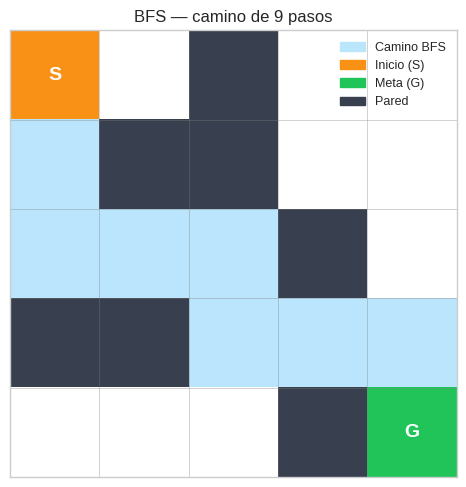

In [8]:
def visualizar_laberinto(grid, camino, inicio, meta, titulo, ax, color_camino=None):
    """Dibuja el laberinto con el camino encontrado."""
    if color_camino is None:
        color_camino = [0.73, 0.90, 0.99]  # azul claro
    filas, cols = len(grid), len(grid[0])
    img = np.ones((filas, cols, 3))

    # Color base
    for r in range(filas):
        for c in range(cols):
            if grid[r][c] == '#':
                img[r, c] = [0.22, 0.25, 0.31]  # pared oscura

    # Camino
    if camino:
        for (r, c) in camino:
            img[r, c] = color_camino

    # Inicio y meta
    img[inicio[0], inicio[1]] = [0.98, 0.57, 0.09]  # naranja
    img[meta[0],   meta[1]]   = [0.13, 0.77, 0.35]  # verde

    ax.imshow(img, interpolation='nearest', aspect='equal')

    # Etiquetas en celdas
    for r in range(filas):
        for c in range(cols):
            if (r, c) == inicio:
                ax.text(c, r, 'S', ha='center', va='center', fontsize=14,
                        fontweight='bold', color='white')
            elif (r, c) == meta:
                ax.text(c, r, 'G', ha='center', va='center', fontsize=14,
                        fontweight='bold', color='white')

    # Líneas de cuadrícula
    for x in range(cols + 1):
        ax.axvline(x - 0.5, color='gray', linewidth=0.5, alpha=0.5)
    for y in range(filas + 1):
        ax.axhline(y - 0.5, color='gray', linewidth=0.5, alpha=0.5)

    ax.set_title(titulo, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])


fig, ax = plt.subplots(figsize=(5, 5))
visualizar_laberinto(maze, camino_bfs, inicio, meta, f"BFS — camino de {len(camino_bfs)} pasos", ax)

parches = [
    mpatches.Patch(color=[0.73, 0.90, 0.99], label='Camino BFS'),
    mpatches.Patch(color=[0.98, 0.57, 0.09], label='Inicio (S)'),
    mpatches.Patch(color=[0.13, 0.77, 0.35], label='Meta (G)'),
    mpatches.Patch(color=[0.22, 0.25, 0.31], label='Pared'),
]
ax.legend(handles=parches, loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Sección 3: DFS en el Mismo Laberinto

DFS usa una **pila** (LIFO): siempre explora el nodo descubierto más recientemente.
Esto hace que DFS se "sumerja" profundamente por un camino antes de explorar alternativas.

**Propiedad clave:** DFS **no** garantiza encontrar el camino más corto. Puede encontrar
un camino más largo que BFS, o incluso un camino muy largo si tiene mala suerte con el orden
de los vecinos.

Sin embargo, DFS usa **mucha menos memoria**: su frontera tiene a lo sumo $O(\text{profundidad})$
nodos, mientras que BFS puede tener $O(b^d)$ nodos en la frontera (donde $b$ es el factor
de ramificación y $d$ la profundidad de la solución).


DFS encontró camino: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]
Longitud del camino: 9 pasos
Nodos expandidos:    9
Máx. tamaño frontera:3


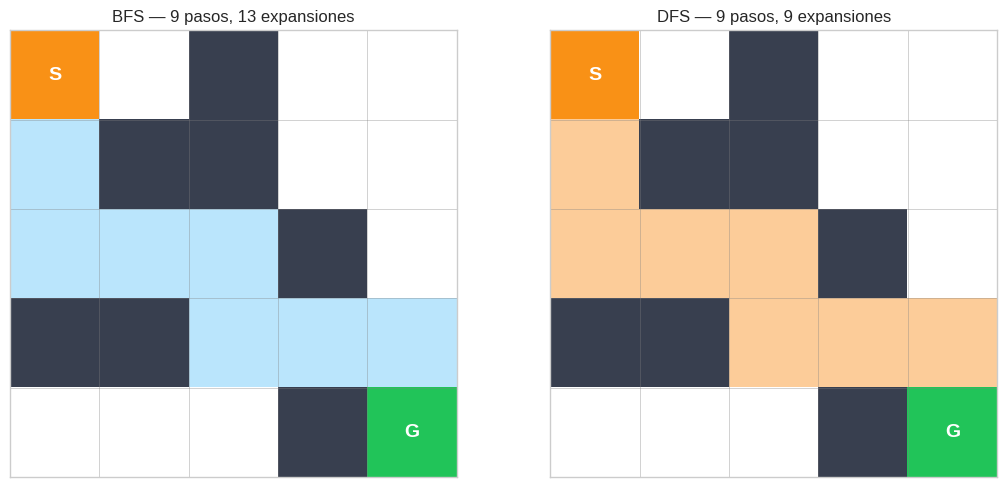


DFS encontró un camino 0 paso(s) más largo que BFS.
BFS siempre da el camino ÓPTIMO (más corto) en grafos sin pesos.


In [9]:
camino_dfs, exp_dfs, max_f_dfs = dfs(problema)

print(f"DFS encontró camino: {camino_dfs}")
print(f"Longitud del camino: {len(camino_dfs)} pasos")
print(f"Nodos expandidos:    {exp_dfs}")
print(f"Máx. tamaño frontera:{max_f_dfs}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
visualizar_laberinto(maze, camino_bfs, inicio, meta,
                     f"BFS — {len(camino_bfs)} pasos, {exp_bfs} expansiones",
                     axes[0], color_camino=[0.73, 0.90, 0.99])
visualizar_laberinto(maze, camino_dfs, inicio, meta,
                     f"DFS — {len(camino_dfs)} pasos, {exp_dfs} expansiones",
                     axes[1], color_camino=[0.99, 0.80, 0.60])
plt.tight_layout()
plt.show()

diferencia = len(camino_dfs) - len(camino_bfs)
print(f"\nDFS encontró un camino {diferencia} paso(s) más largo que BFS.")
print("BFS siempre da el camino ÓPTIMO (más corto) en grafos sin pesos.")


---
## Sección 4: IDDFS — Lo Mejor de Ambos Mundos

**Iterative Deepening DFS (IDDFS)** combina:
- La **optimalidad** de BFS (encuentra el camino más corto)
- El **uso de memoria** de DFS ($O(\text{profundidad})$ en la frontera)

La idea: ejecutar DFS con límite de profundidad $d = 0, 1, 2, \ldots$ hasta encontrar la meta.
El primer $d$ que produce una solución es la profundidad óptima.

**¿No es muy costoso re-explorar nodos?**

Sorprendentemente, no. Si el factor de ramificación es $b$, la iteración $d$ visita
$O(b^d)$ nodos. Pero la iteración anterior visitó $O(b^{d-1})$, que es una fracción pequeña.
En total, el costo es $O(b^d)$ — el mismo orden que BFS.

$$\text{Costo IDDFS} = \sum_{i=0}^{d} b^i = O(b^d) = O(\text{Costo BFS})$$


In [10]:
resultado_iddfs, exp_iddfs, max_f_iddfs, prof_solucion = iddfs(problema)

print(f"IDDFS encontró camino: {resultado_iddfs}")
print(f"Longitud del camino:   {len(resultado_iddfs)} pasos")
print(f"Profundidad solución:  d = {prof_solucion}")
print(f"Nodos expandidos (total, todas las iteraciones): {exp_iddfs}")
print()

# Mostrar que IDDFS itera por profundidad
print("Detalle de iteraciones IDDFS:")
for d in range(prof_solucion + 1):
    res, exp_d, _ = dfs_con_limite(problema, d)
    encontro = '✓ SOLUCIÓN ENCONTRADA' if res is not None else '✗ sin solución'
    print(f"  Límite d={d}: {exp_d:3d} nodos expandidos — {encontro}")


IDDFS encontró camino: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]
Longitud del camino:   9 pasos
Profundidad solución:  d = 8
Nodos expandidos (total, todas las iteraciones): 55

Detalle de iteraciones IDDFS:
  Límite d=0:   1 nodos expandidos — ✗ sin solución
  Límite d=1:   3 nodos expandidos — ✗ sin solución
  Límite d=2:   4 nodos expandidos — ✗ sin solución
  Límite d=3:   5 nodos expandidos — ✗ sin solución
  Límite d=4:   6 nodos expandidos — ✗ sin solución
  Límite d=5:   7 nodos expandidos — ✗ sin solución
  Límite d=6:   9 nodos expandidos — ✗ sin solución
  Límite d=7:  11 nodos expandidos — ✗ sin solución
  Límite d=8:   9 nodos expandidos — ✓ SOLUCIÓN ENCONTRADA


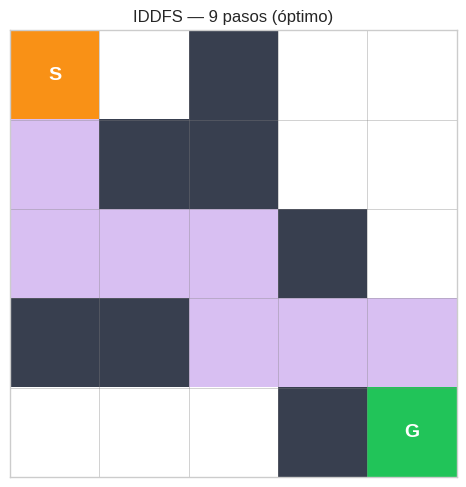

✓ IDDFS y BFS coinciden en longitud óptima: 9 pasos


In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
visualizar_laberinto(maze, resultado_iddfs, inicio, meta,
                     f"IDDFS — {len(resultado_iddfs)} pasos (óptimo)", ax,
                     color_camino=[0.85, 0.75, 0.95])
plt.tight_layout()
plt.show()

assert len(resultado_iddfs) == len(camino_bfs), "IDDFS debe encontrar camino óptimo"
print(f"✓ IDDFS y BFS coinciden en longitud óptima: {len(camino_bfs)} pasos")


---
## Sección 5: Tabla Comparativa

Resumimos el desempeño de los tres algoritmos en el mismo laberinto 5×5.

Recordemos las propiedades teóricas:

| Propiedad | BFS | DFS | IDDFS |
|-----------|-----|-----|-------|
| **Completo** (encuentra solución si existe) | ✓ | ✓* | ✓ |
| **Óptimo** (camino más corto) | ✓ | ✗ | ✓ |
| **Tiempo** | $O(b^d)$ | $O(b^m)$ | $O(b^d)$ |
| **Memoria** (frontera) | $O(b^d)$ | $O(bm)$ | $O(bd)$ |

Donde $b$ = factor de ramificación, $d$ = profundidad de la solución óptima, $m$ = profundidad máxima del árbol.

*DFS puede ciclar en grafos con ciclos si no se lleva registro de explorados.
Con la lista de explorados que usamos, DFS es completo en grafos finitos.


In [12]:
print("Resultados en el laberinto 5×5:")
print()
print(f"{'Algoritmo':<12} {'Nodos expandidos':>18} {'Longitud camino':>16}")
print("-" * 50)
print(f"{'BFS':<12} {exp_bfs:>18} {len(camino_bfs):>16}")
print(f"{'DFS':<12} {exp_dfs:>18} {len(camino_dfs):>16}")
print(f"{'IDDFS':<12} {exp_iddfs:>18} {len(resultado_iddfs):>16}")
print()
print("Observaciones:")
print(f"• BFS y IDDFS encuentran el camino ÓPTIMO de {len(camino_bfs)} pasos.")
print(f"• DFS puede encontrar un camino subóptimo ({len(camino_dfs)} pasos).")
print(f"• IDDFS expande más nodos que BFS por las re-exploraciones.")
print(f"• En laberintos pequeños las diferencias son leves; en grafos grandes son cruciales.")


Resultados en el laberinto 5×5:

Algoritmo      Nodos expandidos  Longitud camino
--------------------------------------------------
BFS                          13                9
DFS                           9                9
IDDFS                        55                9

Observaciones:
• BFS y IDDFS encuentran el camino ÓPTIMO de 9 pasos.
• DFS puede encontrar un camino subóptimo (9 pasos).
• IDDFS expande más nodos que BFS por las re-exploraciones.
• En laberintos pequeños las diferencias son leves; en grafos grandes son cruciales.


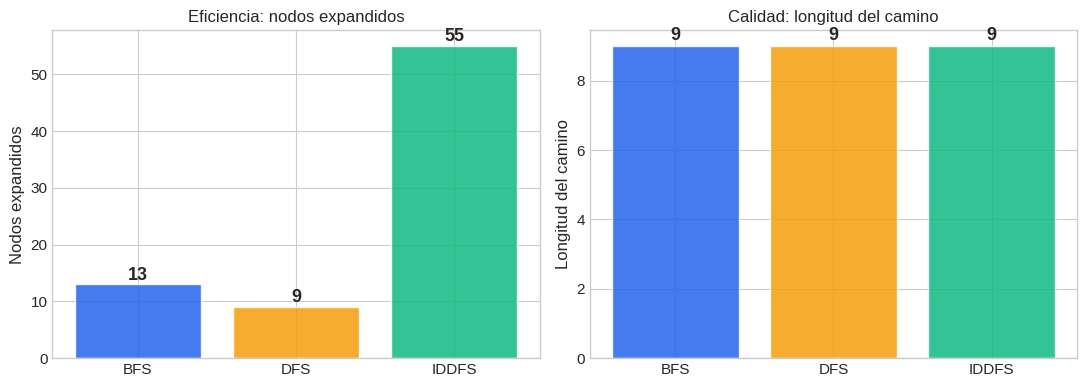

In [13]:
# Gráfica de barras comparativa
algoritmos = ['BFS', 'DFS', 'IDDFS']
expandidos = [exp_bfs, exp_dfs, exp_iddfs]
longitudes = [len(camino_bfs), len(camino_dfs), len(resultado_iddfs)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = [COLORS["primary"], COLORS["accent"], COLORS["secondary"]]

axes[0].bar(algoritmos, expandidos, color=colores, alpha=0.85, edgecolor='white')
axes[0].set_ylabel("Nodos expandidos", fontsize=12)
axes[0].set_title("Eficiencia: nodos expandidos", fontsize=12)
for i, v in enumerate(expandidos):
    axes[0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[1].bar(algoritmos, longitudes, color=colores, alpha=0.85, edgecolor='white')
axes[1].set_ylabel("Longitud del camino", fontsize=12)
axes[1].set_title("Calidad: longitud del camino", fontsize=12)
for i, v in enumerate(longitudes):
    axes[1].text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🔧 Ejercicios

### Ejercicio 1: Laberinto más grande

Crea un laberinto de 10×10 con más paredes y ejecuta BFS, DFS e IDDFS.

1. ¿La diferencia en nodos expandidos crece con el tamaño del laberinto?
2. Mide el tiempo de ejecución de cada algoritmo con `time.perf_counter()`.
3. Visualiza los tres caminos en subplots lado a lado.

```python
import time

maze10 = [
    ['.','.','.','#','.','.','.','#','.','.'],
    ['.','#','.','#','.','#','.','.','.','#'],
    ['.','#','.','.','.','.','#','.','#','.'],
    ['.','.','#','#','.','#','.','.','.','.'],
    ['.','#','.','.','.','.','.','.','#','.'],
    ['.','.','.','.','#','.','#','.','.','.'],
    ['.','#','#','.','.','.','.','#','.','.'],
    ['.','.','.','.','#','.','.','.','#','.'],
    ['.','#','.','.','.','.','#','.','.','#'],
    ['.','.','.','.','.','.','.','.','.','.'],
]
# Tu código aquí
```

### Ejercicio 2: Bidirectional BFS

BFS bidireccional lanza BFS simultáneamente desde el inicio y desde la meta.
Se detiene cuando las dos fronteras se encuentran.

Implementa `bfs_bidireccional(problema)` que devuelva el camino y el número de nodos expandidos.
Compara contra BFS unidireccional en el laberinto de este notebook.

*Pista:* Necesitas dos fronteras (`frontera_inicio`, `frontera_meta`), dos conjuntos de explorados
y dos dicts de padre. Cuando un nodo de una frontera aparece en la otra, reconstruye el camino
concatenando los dos subcaminos.

### Ejercicio 3: Costo uniforme — grafo ponderado

BFS asume que todas las aristas tienen el mismo costo. Considera este grafo ponderado:

```python
grafo_pesos = {
    'A': [('B', 1), ('C', 5)],
    'B': [('D', 2), ('E', 1)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 3)],
    'F': [],
}
```

¿Cuál es el camino de menor costo de A a F? BFS diría `A → C → F` (2 saltos),
pero el costo es $5 + 1 = 6$. El camino `A → B → E → F` tiene costo $1 + 1 + 3 = 5$.

Implementa **Uniform Cost Search** (UCS) usando una cola de prioridad (`heapq`).
Verifica que encuentra el camino de costo mínimo.


Resultados en el laberinto 10x10:
Algoritmo   Nodos exp  Long. camino  Tiempo (ms)
--------------------------------------------------
BFS                75            19        0.194
DFS                42            19        0.124
IDDFS             614            19        1.130

BFS y IDDFS encuentran el camino OPTIMO de 19 pasos.
DFS puede encontrar un camino suboptimo (19 pasos).
Comparacion de expansion: 5x5 -> BFS=13, DFS=9  |  10x10 -> BFS=75, DFS=42
La diferencia entre algoritmos crece con el tamano del laberinto.


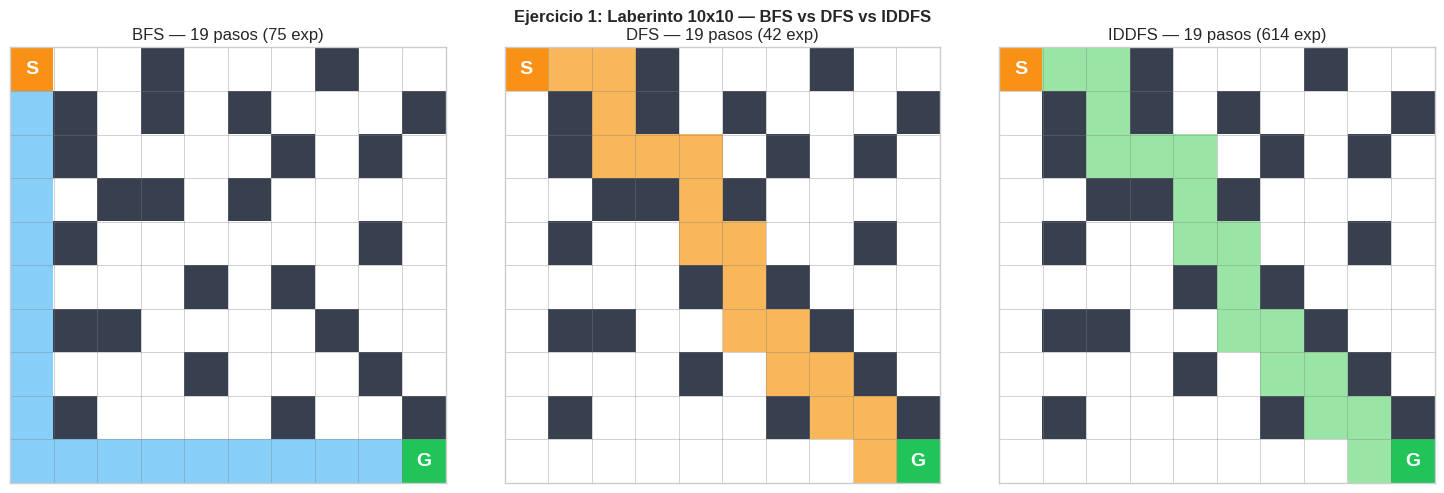

In [14]:
# ── Ejercicio 1: Laberinto 10x10 ─────────────────────────────────────────────

import time

maze10 = [
    ['.','.','.','#','.','.','.','#','.','.'],
    ['.','#','.','#','.','#','.','.','.','#'],
    ['.','#','.','.','.','.','#','.','#','.'],
    ['.','.','#','#','.','#','.','.','.','.'],
    ['.','#','.','.','.','.','.','.','#','.'],
    ['.','.','.','.','#','.','#','.','.','.'],
    ['.','#','#','.','.','.','.','#','.','.'],
    ['.','.','.','.','#','.','.','.','#','.'],
    ['.','#','.','.','.','.','#','.','.','#'],
    ['.','.','.','.','.','.','.','.','.','.'],
]
inicio10, meta10 = (0, 0), (9, 9)
prob10 = ProblemaCuadricula(maze10, inicio10, meta10)

# BFS
t0 = time.perf_counter()
cam_bfs10, exp_bfs10, _ = bfs(prob10)
t_bfs10 = time.perf_counter() - t0

# DFS
t0 = time.perf_counter()
cam_dfs10, exp_dfs10, _ = dfs(prob10)
t_dfs10 = time.perf_counter() - t0

# IDDFS
t0 = time.perf_counter()
cam_iddfs10, exp_iddfs10, _, _ = iddfs(prob10)
t_iddfs10 = time.perf_counter() - t0

print("Resultados en el laberinto 10x10:")
print(f"{'Algoritmo':<10} {'Nodos exp':>10} {'Long. camino':>13} {'Tiempo (ms)':>12}")
print("-" * 50)
print(f"{'BFS':<10} {exp_bfs10:>10} {len(cam_bfs10):>13} {t_bfs10*1000:>12.3f}")
print(f"{'DFS':<10} {exp_dfs10:>10} {len(cam_dfs10):>13} {t_dfs10*1000:>12.3f}")
print(f"{'IDDFS':<10} {exp_iddfs10:>10} {len(cam_iddfs10):>13} {t_iddfs10*1000:>12.3f}")

print()
print(f"BFS y IDDFS encuentran el camino OPTIMO de {len(cam_bfs10)} pasos.")
print(f"DFS puede encontrar un camino suboptimo ({len(cam_dfs10)} pasos).")
bfs5, dfs5, iddfs5 = exp_bfs, exp_dfs, exp_iddfs  # del laberinto 5x5
print(f"Comparacion de expansion: 5x5 -> BFS={bfs5}, DFS={dfs5}  |  10x10 -> BFS={exp_bfs10}, DFS={exp_dfs10}")
print("La diferencia entre algoritmos crece con el tamano del laberinto.")

# Visualizar los 3 caminos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores_algo = [
    ([0.53, 0.81, 0.98], f'BFS — {len(cam_bfs10)} pasos ({exp_bfs10} exp)', cam_bfs10),
    ([0.98, 0.72, 0.35], f'DFS — {len(cam_dfs10)} pasos ({exp_dfs10} exp)', cam_dfs10),
    ([0.60, 0.90, 0.65], f'IDDFS — {len(cam_iddfs10)} pasos ({exp_iddfs10} exp)', cam_iddfs10),
]
for ax, (color, titulo, cam) in zip(axes, colores_algo):
    visualizar_laberinto(maze10, cam, inicio10, meta10, titulo, ax, color_camino=color)
plt.suptitle('Ejercicio 1: Laberinto 10x10 — BFS vs DFS vs IDDFS', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Comparacion BFS unidireccional vs bidireccional — laberinto 5x5:
  BFS unidireccional:  13 nodos expandidos, camino=9 pasos
  BFS bidireccional:   11 nodos expandidos, camino=9 pasos
  Ahorro: 2 nodos (15% menos)

Laberinto 10x10:
  BFS unidireccional:  75 nodos expandidos
  BFS bidireccional:   43 nodos expandidos
  Ahorro: 32 nodos (43% menos)


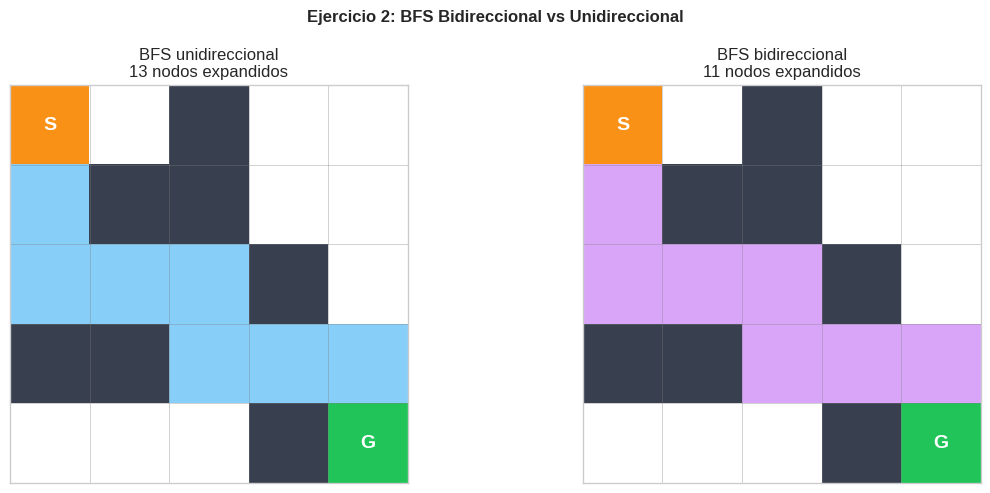


Ventaja del BFS bidireccional: en vez de explorar O(b^d) nodos,
explora dos fronteras de O(b^(d/2)) cada una — exponencialmente mejor.
La ganancia crece con el tamano del grafo y la longitud del camino.


In [15]:
# ── Ejercicio 2: BFS Bidireccional ───────────────────────────────────────────

def bfs_bidireccional(problema):
    """
    BFS bidireccional: lanza BFS simultaneamente desde inicio y desde meta.
    Se detiene cuando las dos fronteras se encuentran.
    Retorna: camino, nodos_expandidos
    """
    inicio, meta = problema.inicio, problema.meta
    if inicio == meta:
        return [inicio], 0

    # Dos fronteras, dos explorados, dos dicts de padre
    frontera_i = deque([inicio])
    frontera_m = deque([meta])
    padre_i = {inicio: None}   # inicio -> nodo siguiente hacia meta
    padre_m = {meta: None}     # meta   -> nodo siguiente hacia inicio
    vis_i = {inicio}
    vis_m = {meta}
    nodos_expandidos = 0

    def reconstruir(punto_encuentro):
        """Une los dos subcaminos en el punto de encuentro."""
        # Camino desde inicio hasta punto_encuentro
        cam_i = []
        n = punto_encuentro
        while n is not None:
            cam_i.append(n)
            n = padre_i[n]
        cam_i.reverse()
        # Camino desde punto_encuentro hasta meta
        cam_m = []
        n = padre_m[punto_encuentro]
        while n is not None:
            cam_m.append(n)
            n = padre_m[n]
        return cam_i + cam_m

    while frontera_i or frontera_m:
        # Expansion desde el inicio
        if frontera_i:
            nodo = frontera_i.popleft()
            nodos_expandidos += 1
            for vecino in problema.vecinos(nodo):
                if vecino not in vis_i:
                    vis_i.add(vecino)
                    padre_i[vecino] = nodo
                    frontera_i.append(vecino)
                    if vecino in vis_m:  # encuentro!
                        return reconstruir(vecino), nodos_expandidos

        # Expansion desde la meta
        if frontera_m:
            nodo = frontera_m.popleft()
            nodos_expandidos += 1
            for vecino in problema.vecinos(nodo):
                if vecino not in vis_m:
                    vis_m.add(vecino)
                    padre_m[vecino] = nodo
                    frontera_m.append(vecino)
                    if vecino in vis_i:  # encuentro!
                        return reconstruir(vecino), nodos_expandidos

    return None, nodos_expandidos  # sin camino


# Comparar en el laberinto 5x5
cam_bidir, exp_bidir = bfs_bidireccional(problema)
print("Comparacion BFS unidireccional vs bidireccional — laberinto 5x5:")
print(f"  BFS unidireccional: {exp_bfs:3d} nodos expandidos, camino={len(camino_bfs)} pasos")
print(f"  BFS bidireccional:  {exp_bidir:3d} nodos expandidos, camino={len(cam_bidir) if cam_bidir else 0} pasos")
ahorro = exp_bfs - exp_bidir
print(f"  Ahorro: {ahorro} nodos ({ahorro/exp_bfs:.0%} menos)")

# Tambien comparar en el 10x10
cam_bidir10, exp_bidir10 = bfs_bidireccional(prob10)
print(f"\nLaberinto 10x10:")
print(f"  BFS unidireccional: {exp_bfs10:3d} nodos expandidos")
print(f"  BFS bidireccional:  {exp_bidir10:3d} nodos expandidos")
ahorro10 = exp_bfs10 - exp_bidir10
print(f"  Ahorro: {ahorro10} nodos ({ahorro10/exp_bfs10:.0%} menos)")

# Visualizar encuentro de fronteras en 5x5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
visualizar_laberinto(maze, camino_bfs, inicio, meta,
    f'BFS unidireccional\n{exp_bfs} nodos expandidos', axes[0],
    color_camino=[0.53, 0.81, 0.98])
if cam_bidir:
    visualizar_laberinto(maze, cam_bidir, inicio, meta,
        f'BFS bidireccional\n{exp_bidir} nodos expandidos', axes[1],
        color_camino=[0.85, 0.65, 0.98])
plt.suptitle('Ejercicio 2: BFS Bidireccional vs Unidireccional', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("Ventaja del BFS bidireccional: en vez de explorar O(b^d) nodos,")
print("explora dos fronteras de O(b^(d/2)) cada una — exponencialmente mejor.")
print("La ganancia crece con el tamano del grafo y la longitud del camino.")


Todos los caminos de A a F (ordenados por costo):
  A -> B -> E -> F          costo = 5
  A -> C -> F               costo = 6

BFS (minimas aristas): A -> C -> F  costo=6  <- SUBOPTIMO
UCS (minimo costo):    A -> B -> E -> F  costo=5  <- OPTIMO

BFS dice A->C->F (2 saltos) pero ese camino cuesta 5+1=6.
UCS encuentra A->B->E->F que cuesta 1+1+3=5 — el verdadero minimo.


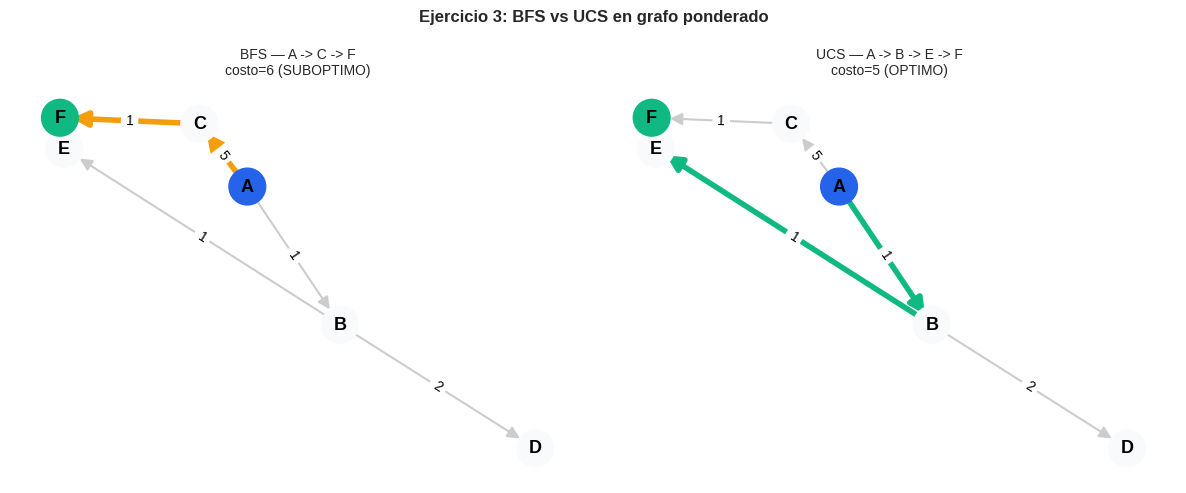


Conclusion: BFS minimiza el NUMERO DE ARISTAS (optimo cuando todos los pesos son iguales).
UCS/Dijkstra minimiza el COSTO TOTAL — necesario cuando los pesos difieren.
UCS es BFS con cola de prioridad en lugar de cola FIFO.


In [ ]:
# ── Ejercicio 3: Uniform Cost Search (UCS) ───────────────────────────────────

import heapq

grafo_pesos = {
    'A': [('B', 1), ('C', 5)],
    'B': [('D', 2), ('E', 1)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 3)],
    'F': [],
}

def ucs(grafo, inicio, meta):
    """
    Uniform Cost Search: expande siempre el nodo con menor costo acumulado g(n).

    """
    # heap: (costo_acumulado, nodo, padre)
    heap = [(0, inicio, None)]
    visitados = set()
    padre = {inicio: None}
    costo_llegada = {inicio: 0}
    nodos_expandidos = 0

    while heap:
        costo, nodo, prev = heapq.heappop(heap)

        if nodo in visitados:
            continue
        visitados.add(nodo)
        padre[nodo] = prev
        nodos_expandidos += 1

        if nodo == meta:
            # Reconstruir camino
            camino = []
            n = meta
            while n is not None:
                camino.append(n)
                n = padre[n]
            camino.reverse()
            return camino, costo, nodos_expandidos

        for vecino, peso in grafo.get(nodo, []):
            nuevo_costo = costo + peso
            if vecino not in visitados and (vecino not in costo_llegada or nuevo_costo < costo_llegada[vecino]):
                costo_llegada[vecino] = nuevo_costo
                heapq.heappush(heap, (nuevo_costo, vecino, nodo))

    return None, float('inf'), nodos_expandidos


# Encontrar todos los caminos para comparar
def todos_caminos_a_f(grafo, inicio, meta):
    """DFS para encontrar todos los caminos posibles (con su costo)."""
    resultados = []
    def dfs_rec(nodo, camino, costo):
        if nodo == meta:
            resultados.append((list(camino), costo)); return
        for v, w in grafo.get(nodo, []):
            if v not in camino:
                camino.append(v)
                dfs_rec(v, camino, costo + w)
                camino.pop()
    dfs_rec(inicio, [inicio], 0)
    return sorted(resultados, key=lambda x: x[1])

print("Todos los caminos de A a F (ordenados por costo):")
for cam, costo in todos_caminos_a_f(grafo_pesos, 'A', 'F'):
    print(f"  {' -> '.join(cam):<25} costo = {costo}")

print()
# BFS (cuenta aristas, no costos)
def bfs_simple(grafo, inicio, meta):
    cola = deque([(inicio, [inicio])]); vis = {inicio}
    while cola:
        n, cam = cola.popleft()
        if n == meta: return cam
        for v, _ in grafo.get(n, []):
            if v not in vis: vis.add(v); cola.append((v, cam+[v]))
    return None

cam_bfs_p = bfs_simple(grafo_pesos, 'A', 'F')
costo_bfs = sum(w for u,vs in grafo_pesos.items() for v,w in vs
                if any(cam_bfs_p[i]==u and cam_bfs_p[i+1]==v for i in range(len(cam_bfs_p)-1)))

cam_ucs, costo_ucs, exp_ucs = ucs(grafo_pesos, 'A', 'F')

print(f"BFS (minimas aristas): {' -> '.join(cam_bfs_p)}  costo={costo_bfs}  <- SUBOPTIMO")
print(f"UCS (minimo costo):    {' -> '.join(cam_ucs)}  costo={costo_ucs}  <- OPTIMO")
print()
print("BFS dice A->C->F (2 saltos) pero ese camino cuesta 5+1=6.")
print("UCS encuentra A->B->E->F que cuesta 1+1+3=5 — el verdadero minimo.")

# Visualizar el grafo ponderado con ambos caminos
import networkx as nx
G_p = nx.DiGraph()
for u, vs in grafo_pesos.items():
    for v, w in vs:
        G_p.add_edge(u, v, weight=w)

pos_p = nx.spring_layout(G_p, seed=3)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (cam, titulo, color_ruta) in zip(axes, [
    (cam_bfs_p, f'BFS — {" -> ".join(cam_bfs_p)}\ncosto={costo_bfs} (SUBOPTIMO)', COLORS['accent']),
    (cam_ucs,   f'UCS — {" -> ".join(cam_ucs)}\ncosto={costo_ucs} (OPTIMO)',    COLORS['secondary']),
]):
    aristas_ruta = [(cam[i], cam[i+1]) for i in range(len(cam)-1)]
    colores_n = [COLORS['primary'] if n == 'A' else
                 (COLORS['secondary'] if n == 'F' else COLORS['empty']) for n in G_p.nodes()]
    nx.draw_networkx(G_p, pos=pos_p, ax=ax, node_color=colores_n,
                     node_size=700, font_size=13, font_weight='bold',
                     edge_color='#cccccc', width=1.5, arrows=True, arrowsize=18)
    nx.draw_networkx_edges(G_p, pos=pos_p, ax=ax, edgelist=aristas_ruta,
                           edge_color=color_ruta, width=4, arrows=True, arrowsize=22)
    labels_w = nx.get_edge_attributes(G_p, 'weight')
    nx.draw_networkx_edge_labels(G_p, pos=pos_p, ax=ax, edge_labels=labels_w, font_size=10)
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')

plt.suptitle('Ejercicio 3: BFS vs UCS en grafo ponderado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("Conclusion: BFS minimiza el NUMERO DE ARISTAS (optimo cuando todos los pesos son iguales).")
print("UCS/Dijkstra minimiza el COSTO TOTAL — necesario cuando los pesos difieren.")
print("UCS es BFS con cola de prioridad en lugar de cola FIFO.")
